# Deep LDA Calibration Experiments

Train Deep LDA on CIFAR-10 and Fashion-MNIST with `DNLLLoss` and `LogisticLoss`, then save confidence histograms and reliability diagrams for each trained model.

### Setup

In [1]:
import os
import sys
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

for module_dir in (Path.cwd(), Path.cwd() / 'logistic-loss'):
    if (module_dir / 'lda.py').exists():
        sys.path.insert(0, str(module_dir))
        break

from lda import LDAHead, DNLLLoss, LogisticLoss

os.makedirs('plots', exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pin_memory = torch.cuda.is_available()
print('device =', device)


device = cuda


### Shared Deep LDA model and utilities

In [ ]:
class ConvEncoder(nn.Module):
    def __init__(self, in_channels, dim):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.proj = nn.Linear(256, dim)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.proj(x)


class DeepLDA(nn.Module):
    def __init__(self, num_classes, latent_dim, in_channels, covariance_type='spherical'):
        super().__init__()
        self.encoder = ConvEncoder(in_channels, latent_dim)
        self.head = LDAHead(num_classes, latent_dim, covariance_type=covariance_type)

    def forward(self, x):
        z = self.encoder(x)
        return self.head(z)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ok = tot = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        ok += (logits.argmax(1) == y).sum().item()
        tot += y.size(0)
    return ok / tot


def train_deep_lda(name, train_loader, test_loader, num_classes, latent_dim, in_channels, loss_fn, epochs=100, lr=1e-3):
    model = DeepLDA(num_classes, latent_dim, in_channels).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    train_acc, test_acc = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum = acc_sum = n_sum = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            with torch.no_grad():
                pred = logits.argmax(1)
                acc_sum += (pred == y).sum().item()
                n_sum += y.size(0)
                loss_sum += loss.item() * y.size(0)

        tr_acc = acc_sum / n_sum
        te_acc = evaluate(model, test_loader)
        train_acc.append(tr_acc)
        test_acc.append(te_acc)
        print(f'[{name} {epoch:02d}] train loss={loss_sum/n_sum:.4f} acc={tr_acc:.4f} | test acc={te_acc:.4f}')

    return model, {'train_acc': train_acc, 'test_acc': test_acc}


@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    conf_list, pred_list, label_list = [], [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        conf, pred = probs.max(1)
        conf_list.append(conf.cpu())
        pred_list.append(pred.cpu())
        label_list.append(y.cpu())

    conf = torch.cat(conf_list).numpy()
    pred = torch.cat(pred_list).numpy()
    labels = torch.cat(label_list).numpy()
    return conf, pred, labels


In [18]:
def plot_confidence_hist(model, loader, out_path, title, n_bins=20):
    conf, pred, labels = collect_predictions(model, loader)
    acc = (pred == labels).mean()
    avg_conf = conf.mean()
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    weights = np.ones_like(conf) / conf.size

    plt.figure(figsize=(4.5, 4.5))
    plt.hist(conf, bins=bins, weights=weights, color='steelblue', edgecolor='black')
    ymax = plt.gca().get_ylim()[1]
    plt.axvline(avg_conf, color='dimgray', linestyle='--', linewidth=2)
    plt.axvline(acc, color='black', linestyle=':', linewidth=2)
    plt.text(avg_conf, 0.95 * ymax, 'Avg confidence', rotation=90, va='top', ha='center')
    plt.text(acc, 0.95 * ymax, 'Accuracy', rotation=90, va='top', ha='center')
    #plt.title(title)
    plt.xlabel('Confidence')
    plt.ylabel('% of samples')
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.savefig(out_path, dpi=600)
    plt.show()


def plot_reliability_diagram(model, loader, out_path, title, n_bins=10):
    conf, pred, labels = collect_predictions(model, loader)
    correct = (pred == labels).astype(np.float32)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(conf, bins[1:-1], right=True)

    bin_acc = np.zeros(n_bins, dtype=np.float32)
    bin_conf = np.zeros(n_bins, dtype=np.float32)
    bin_frac = np.zeros(n_bins, dtype=np.float32)

    for b in range(n_bins):
        mask = bin_ids == b
        if mask.any():
            bin_acc[b] = correct[mask].mean()
            bin_conf[b] = conf[mask].mean()
            bin_frac[b] = mask.mean()

    ece = np.sum(np.abs(bin_acc - bin_conf) * bin_frac)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_width = bins[1] - bins[0]

    plt.figure(figsize=(4.5, 4.5))
    plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=2)
    plt.bar(bin_centers, bin_acc, width=bin_width, color='steelblue', edgecolor='black', label='Accuracy')
    gap = bin_conf - bin_acc
    plt.bar(bin_centers, gap, bottom=bin_acc, width=bin_width, color='salmon', edgecolor='red', alpha=0.4, hatch='//', label='Gap')
    #plt.title(title)
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend(loc='upper left')
    plt.text(0.95, 0.05, f'ECE={ece*100:.2f}', ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='lightsteelblue', alpha=0.8))
    plt.tight_layout()
    plt.savefig(out_path, dpi=600)
    plt.show()


## CIFAR-10

### Data

In [3]:
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2470, 0.2435, 0.2616)

cifar10_train_tfm = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

cifar10_test_tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar10_mean, cifar10_std),
])

cifar10_train_ds = datasets.CIFAR10(root='./data', train=True, transform=cifar10_train_tfm, download=True)
cifar10_test_ds = datasets.CIFAR10(root='./data', train=False, transform=cifar10_test_tfm, download=True)
cifar10_train_ld = DataLoader(cifar10_train_ds, batch_size=256, shuffle=True, num_workers=4, pin_memory=pin_memory)
cifar10_test_ld = DataLoader(cifar10_test_ds, batch_size=1024, shuffle=False, num_workers=4, pin_memory=pin_memory)
len(cifar10_train_ds), len(cifar10_test_ds)


(50000, 10000)

### Train Deep LDA

In [4]:
cifar10_dnll_model, cifar10_dnll_history = train_deep_lda(
    name='CIFAR-10 DNLL',
    train_loader=cifar10_train_ld,
    test_loader=cifar10_test_ld,
    num_classes=10,
    latent_dim=9,
    in_channels=3,
    loss_fn=DNLLLoss(lambda_reg=0.01),
    epochs=100,
)

cifar10_logistic_model, cifar10_logistic_history = train_deep_lda(
    name='CIFAR-10 Logistic',
    train_loader=cifar10_train_ld,
    test_loader=cifar10_test_ld,
    num_classes=10,
    latent_dim=9,
    in_channels=3,
    loss_fn=LogisticLoss(),
    epochs=100,
)


[CIFAR-10 DNLL 01] train loss=7.3408 acc=0.4104 | test acc=0.4305
[CIFAR-10 DNLL 02] train loss=5.1588 acc=0.5855 | test acc=0.6196
[CIFAR-10 DNLL 03] train loss=3.6087 acc=0.6617 | test acc=0.6382
[CIFAR-10 DNLL 04] train loss=2.1753 acc=0.7061 | test acc=0.6834
[CIFAR-10 DNLL 05] train loss=0.8084 acc=0.7292 | test acc=0.7185
[CIFAR-10 DNLL 06] train loss=-0.4730 acc=0.7504 | test acc=0.7134
[CIFAR-10 DNLL 07] train loss=-1.5306 acc=0.7683 | test acc=0.7418
[CIFAR-10 DNLL 08] train loss=-2.2636 acc=0.7953 | test acc=0.7827
[CIFAR-10 DNLL 09] train loss=-2.6359 acc=0.8153 | test acc=0.7914
[CIFAR-10 DNLL 10] train loss=-2.8334 acc=0.8315 | test acc=0.7812
[CIFAR-10 DNLL 11] train loss=-2.9691 acc=0.8470 | test acc=0.8210
[CIFAR-10 DNLL 12] train loss=-3.0620 acc=0.8597 | test acc=0.7996
[CIFAR-10 DNLL 13] train loss=-3.1104 acc=0.8661 | test acc=0.8177
[CIFAR-10 DNLL 14] train loss=-3.1642 acc=0.8794 | test acc=0.8369
[CIFAR-10 DNLL 15] train loss=-3.1942 acc=0.8853 | test acc=0.8448


In [11]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

### Confidence histograms

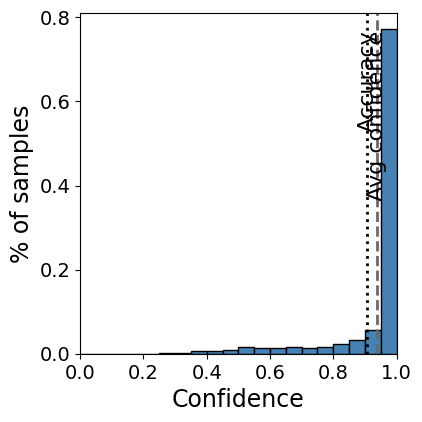

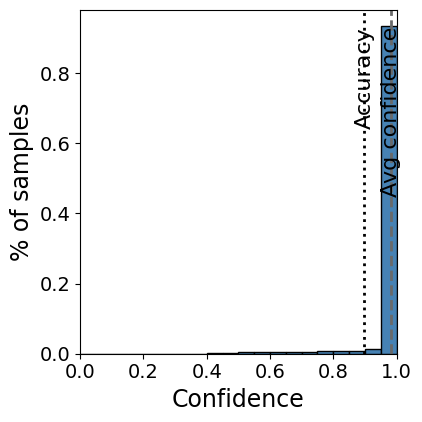

In [19]:
plot_confidence_hist(
    cifar10_dnll_model,
    cifar10_test_ld,
    'plots/cifar10_deeplda_dnll_confidence_hist.png',
    'CIFAR-10 Deep LDA + DNLLLoss',
)
plot_confidence_hist(
    cifar10_logistic_model,
    cifar10_test_ld,
    'plots/cifar10_deeplda_logistic_confidence_hist.png',
    'CIFAR-10 Deep LDA + LogisticLoss',
)


### Reliability diagrams

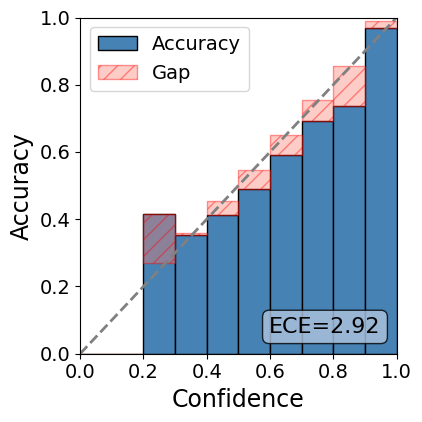

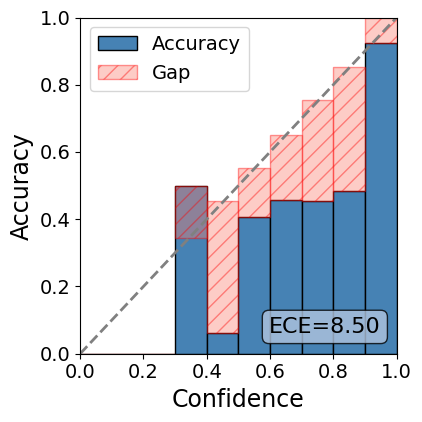

In [22]:
plot_reliability_diagram(
    cifar10_dnll_model,
    cifar10_test_ld,
    'plots/cifar10_deeplda_dnll_reliability_diagram.png',
    'CIFAR-10 Deep LDA + DNLLLoss',
)
plot_reliability_diagram(
    cifar10_logistic_model,
    cifar10_test_ld,
    'plots/cifar10_deeplda_logistic_reliability_diagram.png',
    'CIFAR-10 Deep LDA + LogisticLoss',
)


## Fashion-MNIST

### Data

In [7]:
fashion_train_tfm = transforms.Compose([
    transforms.RandomCrop(28, padding=2),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

fashion_test_tfm = transforms.ToTensor()

fashion_train_ds = datasets.FashionMNIST(root='./data', train=True, transform=fashion_train_tfm, download=True)
fashion_test_ds = datasets.FashionMNIST(root='./data', train=False, transform=fashion_test_tfm, download=True)
fashion_train_ld = DataLoader(fashion_train_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=pin_memory)
fashion_test_ld = DataLoader(fashion_test_ds, batch_size=1024, shuffle=False, num_workers=2, pin_memory=pin_memory)
len(fashion_train_ds), len(fashion_test_ds)


(60000, 10000)

### Train Deep LDA

In [8]:
fashion_dnll_model, fashion_dnll_history = train_deep_lda(
    name='Fashion-MNIST DNLL',
    train_loader=fashion_train_ld,
    test_loader=fashion_test_ld,
    num_classes=10,
    latent_dim=9,
    in_channels=1,
    loss_fn=DNLLLoss(lambda_reg=0.01),
    epochs=100,
)

fashion_logistic_model, fashion_logistic_history = train_deep_lda(
    name='Fashion-MNIST Logistic',
    train_loader=fashion_train_ld,
    test_loader=fashion_test_ld,
    num_classes=10,
    latent_dim=9,
    in_channels=1,
    loss_fn=LogisticLoss(),
    epochs=100,
)


[Fashion-MNIST DNLL 01] train loss=4.4262 acc=0.7673 | test acc=0.8005
[Fashion-MNIST DNLL 02] train loss=2.4550 acc=0.8582 | test acc=0.8414
[Fashion-MNIST DNLL 03] train loss=1.0287 acc=0.8828 | test acc=0.8815
[Fashion-MNIST DNLL 04] train loss=-0.3018 acc=0.8948 | test acc=0.8799
[Fashion-MNIST DNLL 05] train loss=-1.5133 acc=0.9009 | test acc=0.8949
[Fashion-MNIST DNLL 06] train loss=-2.4633 acc=0.9075 | test acc=0.8980
[Fashion-MNIST DNLL 07] train loss=-2.9927 acc=0.9142 | test acc=0.8974
[Fashion-MNIST DNLL 08] train loss=-3.2102 acc=0.9198 | test acc=0.9127
[Fashion-MNIST DNLL 09] train loss=-3.3055 acc=0.9251 | test acc=0.9114
[Fashion-MNIST DNLL 10] train loss=-3.3475 acc=0.9299 | test acc=0.9168
[Fashion-MNIST DNLL 11] train loss=-3.3765 acc=0.9339 | test acc=0.9235
[Fashion-MNIST DNLL 12] train loss=-3.3893 acc=0.9351 | test acc=0.9243
[Fashion-MNIST DNLL 13] train loss=-3.4031 acc=0.9385 | test acc=0.9306
[Fashion-MNIST DNLL 14] train loss=-3.4106 acc=0.9405 | test acc=0.

### Confidence histograms

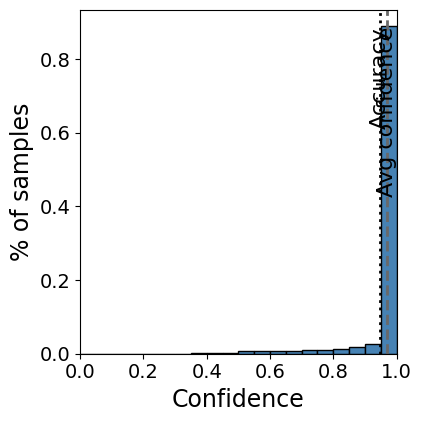

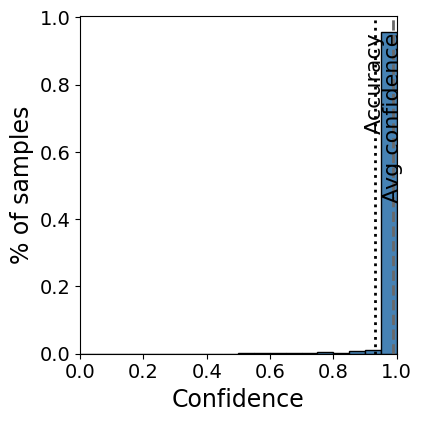

In [20]:
plot_confidence_hist(
    fashion_dnll_model,
    fashion_test_ld,
    'plots/fashion_mnist_deeplda_dnll_confidence_hist.png',
    'Fashion-MNIST Deep LDA + DNLLLoss',
)
plot_confidence_hist(
    fashion_logistic_model,
    fashion_test_ld,
    'plots/fashion_mnist_deeplda_logistic_confidence_hist.png',
    'Fashion-MNIST Deep LDA + LogisticLoss',
)


### Reliability diagrams

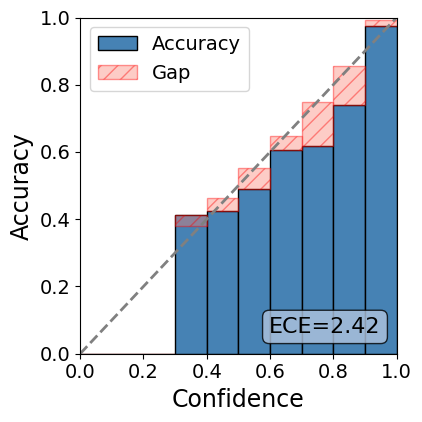

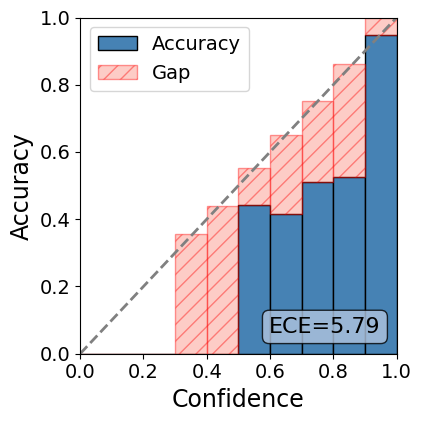

In [21]:
plot_reliability_diagram(
    fashion_dnll_model,
    fashion_test_ld,
    'plots/fashion_mnist_deeplda_dnll_reliability_diagram.png',
    'Fashion-MNIST Deep LDA + DNLLLoss',
)
plot_reliability_diagram(
    fashion_logistic_model,
    fashion_test_ld,
    'plots/fashion_mnist_deeplda_logistic_reliability_diagram.png',
    'Fashion-MNIST Deep LDA + LogisticLoss',
)
